# 08 · Morfología relativa al paciente

**La idea.** Lo que funcionó con el ritmo se aplica ahora a la forma. La v2 dejó de usar el
intervalo RR en segundos y pasó a usarlo **relativo a la mediana del propio paciente**. Acá se hace
lo mismo con la morfología: en vez de describir el latido en absoluto, se lo describe **relativo
al latido dominante de esa persona**.

**Por qué debería funcionar.** El peor modo de falla del proyecto fue el registro 207: sus latidos
con bloqueo de rama izquierda se clasificaban como ventriculares (solo 2.7 % correctos) porque son
anchos y raros *en absoluto*. Pero son la morfología **normal de ese paciente**: comparados con su
propia plantilla, no tienen nada de anómalo.

**La plantilla** es la mediana de los latidos del paciente. No usa etiquetas, así que la API puede
calcularla con el ECG que recibe.

**Decidido antes de correr nada:**

- **Candidatos:** A) v3 actual · B) v3 + features relativas · C) solo RR normalizado + relativas ·
  D) B con el latido residual en lugar del crudo.
- **Criterio:** mayor F1 macro de 3 clases; si empatan dentro de 0.01, gana el que deje **menos
  latidos V sin detectar** (RISK-01).
- Mismos folds congelados, mismos latidos (DS1 sin la clase F), **INCART no se toca**.

> Proyecto educativo y de investigación. No es un dispositivo médico.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ecg import config
from ecg.evaluate import confusion, per_class_metrics, plot_confusion, summary
from ecg.features import build_features, patient_template, relative_morphology_features
from ecg.models.baseline import BaselineClassifier
from ecg.segment import load_split
from ecg.train import BASELINE_V4_CHOICE, BASELINE_V3_CHOICE, CLASSES_V3, cross_validate

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.precision", 3)
FIG_DIR = config.REPORTS_DIR / "figures"

ds1 = load_split("ds1")
keep = ds1["y"] != "F"
X, F = ds1["X"][keep], ds1["F"][keep]
y, groups, symbols = ds1["y"][keep], ds1["record"][keep], ds1["symbol"][keep]

def evaluar(feature_set, template=None, template_block=None, template_beats=None):
    Z, _ = build_features(X, F, feature_set, records=groups, template=template,
                          template_block=template_block, template_beats=template_beats)
    cv = cross_validate(
        lambda: BaselineClassifier(kind="xgb", feature_set=feature_set,
                                   classes=list(CLASSES_V3)),
        Z, y, groups, fold_map=config.DS1_FOLD_MAP, classes=list(CLASSES_V3))
    s = summary(y, cv["pred"], CLASSES_V3)
    return cv["pred"], {**{k: v for k, v in s.items() if v is not None},
                        "V→N": int(((y == "V") & (cv["pred"] == "N")).sum()),
                        "falsas N": int(((y == "N") & (cv["pred"] != "N")).sum()),
                        "errores": int((y != cv["pred"]).sum()), "features": Z.shape[1]}

COLS = ["features", "macro_f1", "N_F1", "S_Se", "S_+P", "S_F1", "V_Se", "V_+P", "V_F1",
        "V→N", "falsas N", "errores"]

## 1. Qué mide una feature relativa

In [2]:
rel, nombres = relative_morphology_features(X, groups)
pd.DataFrame(rel, columns=nombres).assign(clase=y).groupby("clase").median().round(2)

,corr_plantilla,corr_plantilla_qrs,rms_residuo,rms_residuo_qrs,max_residuo,r_amp_menos_plantilla,qrs_ancho_sobre_plantilla
clase,,,,,,,
N,0.99,0.99,0.16,0.19,0.60,0.02,1.00
S,0.85,0.99,0.54,0.38,1.46,-0.23,1.00
V,0.40,0.63,1.06,1.52,3.19,-2.72,2.05


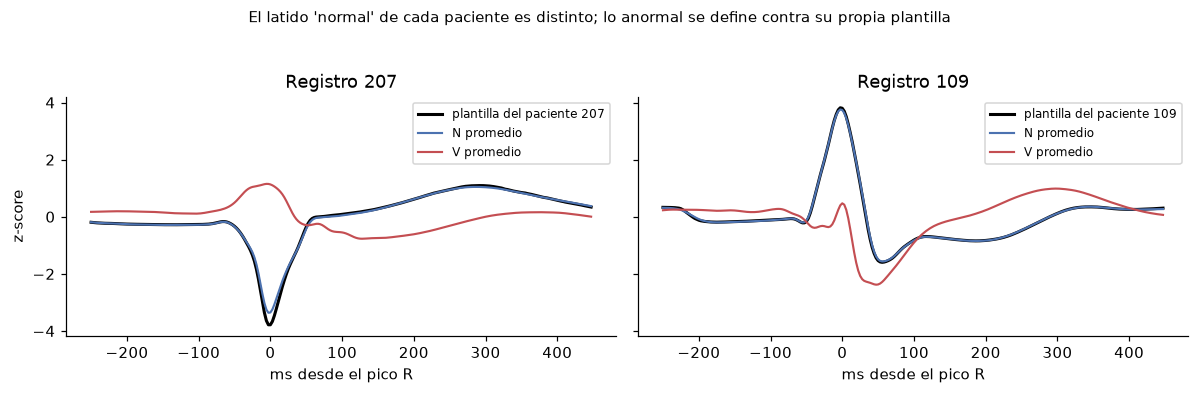

In [3]:
t_ms = (np.arange(config.WINDOW) - config.PRE_SAMPLES) / config.FS * 1000
tpl = patient_template(X, groups)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, rec in zip(axes, [207, 109]):
    m = groups == rec
    ax.plot(t_ms, tpl[m][0], "k", lw=2, label=f"plantilla del paciente {rec}")
    for cls, color in [("N", "#4C72B0"), ("V", "#C44E52")]:
        sel = m & (y == cls)
        if sel.sum():
            ax.plot(t_ms, X[sel].mean(axis=0), color=color, lw=1.4, label=f"{cls} promedio")
    ax.set_title(f"Registro {rec}"); ax.set_xlabel("ms desde el pico R")
axes[0].set_ylabel("z-score"); axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
fig.suptitle("El latido 'normal' de cada paciente es distinto; lo anormal se define contra su propia plantilla",
             y=1.04, fontsize=10)
fig.tight_layout(); fig.savefig(FIG_DIR / "v4_patient_templates.png", bbox_inches="tight")

**Conclusiones:**

- Las features relativas separan las clases con una claridad que las absolutas no tenían. La
  **correlación con la plantilla del propio paciente** vale 0.99 en los latidos N, 0.85 en los S y
  **0.40 en los V**. El ancho del QRS relativo dice lo mismo: un latido V mide **el doble** que el
  latido típico de esa misma persona (2.05).
- La figura muestra por qué esto importa: el latido "normal" del registro 207 (bloqueo de rama) no
  se parece al del 109. En absoluto, el del 207 parece ventricular; **contra su propia plantilla,
  es exactamente lo normal de ese paciente.**
- Para S el aporte es menor, y tiene sentido clínico: un latido supraventricular prematuro se
  conduce por las vías normales, así que **su morfología es casi idéntica a la del latido normal**
  (correlación 0.85). Lo que lo delata es el timing, no la forma.

## 2. Los cuatro candidatos

In [4]:
CANDIDATOS = {
    "A · v3 (morfología absoluta)": "rr_norm+morph+wave",
    "B · v3 + relativas": "rr_norm+morph+rel+wave",
    "C · solo RR + relativas": "rr_norm+rel",
    "D · v3 + relativas + latido residual": "rr_norm+morph+rel+wave_rel",
}
pred, filas = {}, {}
for nombre, fs in CANDIDATOS.items():
    pred[nombre], filas[nombre] = evaluar(fs)
pd.DataFrame(filas).T[COLS].round(3)

,features,macro_f1,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,V→N,falsas N,errores
A · v3 (morfología absoluta),41.0,0.649,0.946,0.376,0.382,0.379,0.914,0.471,0.622,298.0,4136.0,5050.0
B · v3 + relativas,48.0,0.727,0.975,0.383,0.265,0.313,0.937,0.849,0.891,225.0,1522.0,2343.0
C · solo RR + relativas,11.0,0.701,0.973,0.319,0.235,0.271,0.904,0.821,0.861,338.0,1608.0,2612.0
D · v3 + relativas + latido residual,48.0,0.733,0.977,0.368,0.310,0.336,0.928,0.845,0.885,259.0,1312.0,2179.0


**Conclusiones: la mejora es grande.**

- **Los errores caen de 5 050 a 2 343 (−54 %)** con solo 7 features más.
- **La +P de V pasa de 0.471 a 0.849.** Las falsas alarmas sobre latidos normales bajan de 4 136 a
  1 522: el modelo deja de confundir "latido raro para la población" con "latido raro para este
  paciente".
- **Hay un costo real en S:** su +P baja de 0.382 a 0.265. Al desaparecer los falsos V, parte de
  esas falsas alarmas se redistribuye hacia S. Es un intercambio favorable —V es la clase de mayor
  severidad clínica— pero hay que reportarlo.
- **C (solo 11 features)** llega a 0.701 sin morfología absoluta: casi todo el trabajo lo hacen el
  ritmo normalizado y la comparación con la plantilla. Es un modelo muy chico y explicable.
- **D es el mejor en F1 macro (0.733)**, pero queda dentro de 0.01 de **B (0.727)** y la regla
  declarada desempata por latidos V no detectados: **B (225) gana a D (259)**.

## 3. ¿Funciona por la razón que pensábamos?

In [5]:
for rec in (207, 109):
    m = (groups == rec) & (symbols == "L")
    print(f"registro {rec}: {int(m.sum())} latidos con bloqueo de rama (L)")
    for nombre in ["A · v3 (morfología absoluta)", "B · v3 + relativas"]:
        print(f"   {nombre}: {100 * (pred[nombre][m] == 'N').mean():.1f}% clasificados como N")
falsas = pd.DataFrame({nombre: {rec: int(((groups == rec) & (y == "N") & (p != "N")).sum())
                                for rec in [203, 207, 108, 201, 215]}
                       for nombre, p in pred.items()})
falsas.index.name = "registro"
print("\nFalsas alarmas sobre latidos N, por registro:")
falsas

registro 207: 1457 latidos con bloqueo de rama (L)
   A · v3 (morfología absoluta): 2.7% clasificados como N
   B · v3 + relativas: 99.9% clasificados como N
registro 109: 2490 latidos con bloqueo de rama (L)
   A · v3 (morfología absoluta): 91.4% clasificados como N
   B · v3 + relativas: 99.7% clasificados como N

Falsas alarmas sobre latidos N, por registro:


,A · v3 (morfología absoluta),B · v3 + relativas,C · solo RR + relativas,D · v3 + relativas + latido residual
registro,,,,
203,1912,812,761,749
207,1419,2,11,1
108,66,175,349,137
201,449,451,426,388
215,0,0,1,0


**Conclusión: funciona exactamente por la razón que se planteó.**

| Latidos con bloqueo de rama | v3 | v3 + relativas |
|---|---|---|
| Registro 207 (1 457 latidos L) | **2.7 %** | **99.9 %** |
| Registro 109 (2 490 latidos L) | 91.4 % | 99.7 % |

El peor modo de falla de todo el proyecto —1 399 latidos L leídos como V en el 207, detectado en la
Fase 3 y confirmado en DS2— **queda resuelto**. Sus falsas alarmas caen de 1 419 a 2.

También mejora mucho el 203 (fibrilación auricular con ruido): de 1 912 a 812 falsas alarmas.
**No todo mejora:** el registro 108 empeora, de 66 a 175. Es el registro con mayor deriva de línea
base del EDA, y ahí la plantilla es menos estable.

## 4. ¿Cuánta señal necesita la plantilla?

Dos preguntas distintas para la API: cuántos latidos hacen falta, y si la plantilla puede
calcularse una sola vez al inicio o hay que refrescarla.

In [6]:
filas_tpl = {}
for n in [10, 30, 120, 300]:
    _, filas_tpl[f"primeros {n} latidos"] = evaluar("rr_norm+morph+rel+wave", template_beats=n)
for n in [20, 50, 100, 300]:
    _, filas_tpl[f"local · bloques de {n}"] = evaluar("rr_norm+morph+rel+wave", template_block=n)
_, filas_tpl["global (todo el registro)"] = evaluar("rr_norm+morph+rel+wave")
pd.DataFrame(filas_tpl).T[["macro_f1", "S_Se", "V_Se", "V_+P", "V→N", "errores"]].round(3)

,macro_f1,S_Se,V_Se,V_+P,V→N,errores
primeros 10 latidos,0.647,0.350,0.922,0.515,285.0,4694.0
primeros 30 latidos,0.649,0.359,0.919,0.497,297.0,4842.0
primeros 120 latidos,0.661,0.343,0.924,0.619,270.0,3853.0
primeros 300 latidos,0.699,0.359,0.916,0.743,300.0,2863.0
local · bloques de 20,0.725,0.374,0.927,0.831,254.0,2351.0
local · bloques de 50,0.729,0.380,0.940,0.827,220.0,2318.0
local · bloques de 100,0.725,0.371,0.953,0.832,166.0,2355.0
local · bloques de 300,0.719,0.357,0.939,0.825,220.0,2427.0
global (todo el registro),0.727,0.383,0.937,0.849,225.0,2343.0


In [7]:
def plantilla_causal(bloque):
    """Cada bloque usa la mediana del bloque ANTERIOR: lo que podría hacer un sistema en vivo."""
    out = np.empty_like(X)
    for rec in np.unique(groups):
        idx = np.flatnonzero(groups == rec)
        bloques = [idx[i:i + bloque] for i in range(0, len(idx), bloque)]
        for k, b in enumerate(bloques):
            out[b] = np.median(X[bloques[k - 1] if k else b], axis=0)
    return out

_, causal = evaluar("rr_norm+morph+rel+wave", template=plantilla_causal(100))
pd.DataFrame({"causal · bloque previo de 100": causal,
              "local no causal · bloques de 100": filas_tpl["local · bloques de 100"]}).T[
    ["macro_f1", "S_Se", "V_Se", "V_+P", "V→N", "errores"]].round(3)

,macro_f1,S_Se,V_Se,V_+P,V→N,errores
causal · bloque previo de 100,0.715,0.362,0.942,0.788,206.0,2513.0
local no causal · bloques de 100,0.725,0.371,0.953,0.832,166.0,2355.0


**Conclusiones: lo que importa no es el tamaño de la plantilla, sino que esté vigente.**

- Una plantilla calculada **una sola vez al inicio** casi no sirve: con los primeros 10 o 30
  latidos el resultado es 0.647–0.649, **idéntico a no tener features relativas**. Con los primeros
  300 llega a 0.699.
- Una plantilla **local** (recalculada cada N latidos) rinde igual con bloques de 20 que con
  bloques de 300 (0.719–0.729). Es decir: **con 20 latidos contemporáneos alcanza**, pero una
  plantilla de 300 latidos viejos no.
- La conclusión fisiológica es que **la morfología deriva** a lo largo de una grabación de 30
  minutos (postura, contacto del electrodo, ruido), así que la referencia hay que refrescarla.
- **Versión causal (solo latidos previos), viable en tiempo real:** 0.715, apenas por debajo de la
  no causal (0.725) y muy por encima de la v3 (0.649). Es una buena noticia para la API: no hace
  falta tener la grabación completa, pero sí un contexto reciente de unas decenas de latidos.
- Aplicando la regla de desempate entre las opciones dentro de 0.01, queda la **plantilla local de
  100 latidos**: 0.725 con **166 latidos V no detectados**, el mejor valor de todo el proyecto.

## 5. Limitación: pacientes con mayoría de latidos anormales

In [8]:
for nombre, ds in [("DS1", load_split("ds1")), ("INCART", load_split("incart"))]:
    frac = pd.DataFrame({"rec": ds["record"], "anormal": ds["y"] != "N"}).groupby("rec").anormal.mean()
    print(f"{nombre}: máximo {frac.max():.0%} de latidos anormales (registro {frac.idxmax()}); "
          f"registros por encima del 40 %: {sorted(frac[frac > 0.4].index.tolist())}")

DS1: máximo 46% de latidos anormales (registro 208); registros por encima del 40 %: [208]
INCART: máximo 51% de latidos anormales (registro 43); registros por encima del 40 %: [19, 31, 42, 43, 53]


**Conclusión: la plantilla supone que la morfología habitual del paciente es mayoría.**

La mediana aguanta bastante, pero si más de la mitad de los latidos de una persona son anormales,
la plantilla pasa a representar lo anormal y el método se da vuelta. En los datos disponibles el
caso más extremo es el registro 43 de INCART, con **51 % de latidos anormales**, y hay 5 registros
por encima del 40 %. En DS1 el máximo es el 208, con 46 %.

Va documentado como limitación en el model card, y es una de las cosas a vigilar en la validación
externa. Una mitigación posible, no probada acá: construir la plantilla solo con latidos de ritmo
regular (RR ≈ RR local), que también es un criterio sin etiquetas.

## 6. El modelo v4

features: rr_norm+morph+rel+wave | plantilla: bloques de 100 | clases: ['N', 'S', 'V']


,v3 (3 clases),v4 (morfología relativa)
macro_f1,0.649,0.725
N_F1,0.946,0.975
S_Se,0.376,0.371
S_+P,0.382,0.267
V_Se,0.914,0.953
V_+P,0.471,0.832


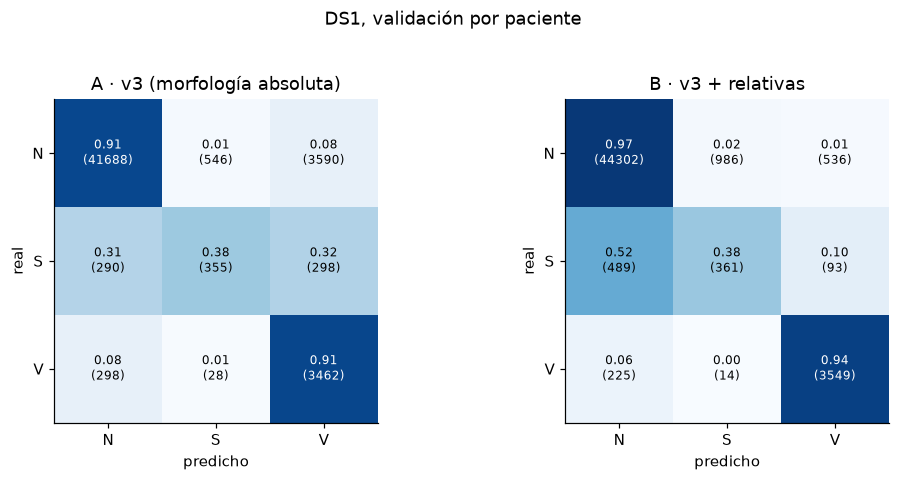

In [9]:
import json

meta = json.loads((config.REPORTS_DIR / "baseline_v4_cv.json").read_text())
print("features:", meta["feature_set"], "| plantilla: bloques de", meta["template_block"],
      "| clases:", meta["classes"])
comparacion = pd.DataFrame({
    "v3 (3 clases)": {k: json.loads((config.REPORTS_DIR / "baseline_v3_cv.json").read_text())["cv"][k]
                      for k in ["macro_f1", "N_F1", "S_Se", "S_+P", "V_Se", "V_+P"]},
    "v4 (morfología relativa)": {k: meta["cv"][k] for k in
                                 ["macro_f1", "N_F1", "S_Se", "S_+P", "V_Se", "V_+P"]},
})
display(comparacion.round(3))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
for ax, nombre in zip(axes, ["A · v3 (morfología absoluta)", "B · v3 + relativas"]):
    p = pred[nombre]
    plot_confusion(confusion(y, p, CLASSES_V3, normalize=True), ax, nombre,
                   counts=confusion(y, p, CLASSES_V3))
fig.suptitle("DS1, validación por paciente", y=1.03)
fig.tight_layout(); fig.savefig(FIG_DIR / "v4_confusion.png", bbox_inches="tight")

## Resumen

**v4 = XGBoost · RR normalizado + morfología absoluta + morfología relativa al paciente ·
3 clases · plantilla local de 100 latidos.**
`python -m ecg.train baseline-v4` → `models/baseline_v4.joblib`.

| | v3 | **v4** |
|---|---|---|
| F1 macro (3 clases) | 0.649 | **0.725** |
| F1 de N | 0.946 | **0.975** |
| Se de V | 0.914 | **0.953** |
| **+P de V** | 0.471 | **0.832** |
| Latidos V no detectados (RISK-01) | 298 | **166** |
| Errores totales | 5 050 | **2 355** |
| F1 de S | 0.379 | 0.311 |

**Lo que se aprendió**

1. **La idea que funcionó con el ritmo funciona con la forma.** Describir el latido relativo al
   paciente, y no en absoluto, **más que dobló** la precisión con que se detectan los latidos
   ventriculares y resolvió el peor modo de falla del proyecto.
2. **Es la misma lección de siempre, ahora como solución:** lo que hace difícil este problema es la
   variabilidad entre pacientes; usarla como referencia, en vez de sufrirla, es lo que mejora.
3. **S sigue sin resolverse** (F1 0.31) y hasta empeora un poco. Su morfología es normal por
   definición, así que el camino para S es el timing, no la forma.
4. La plantilla necesita estar **vigente**, no ser grande. Eso define un requisito de la API:
   contexto reciente de unas decenas de latidos, y una versión causal disponible para tiempo real.

**Lo que falta y es importante:** la v4 **solo está validada en DS1**. DS2 se gastó y INCART se usó
para comparar v1 con v2. Una mejora de este tamaño merece confirmación en una base nueva, y la
candidata es **SVDB** (MIT-BIH Supraventricular Arrhythmia Database), que además es rica en
latidos S, la clase que sigue floja.